In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Adjust the path if your notebook is in the 'notebooks' folder
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Convert date to datetime and handle timezones
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# Basic cleaning: remove extra spaces and lowercase
df['headline'] = df['headline'].str.strip().str.lower()

print(f"Dataset loaded: {df.shape[0]} articles found.")

Dataset loaded: 1407328 articles found.


--- Headline Statistics ---
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


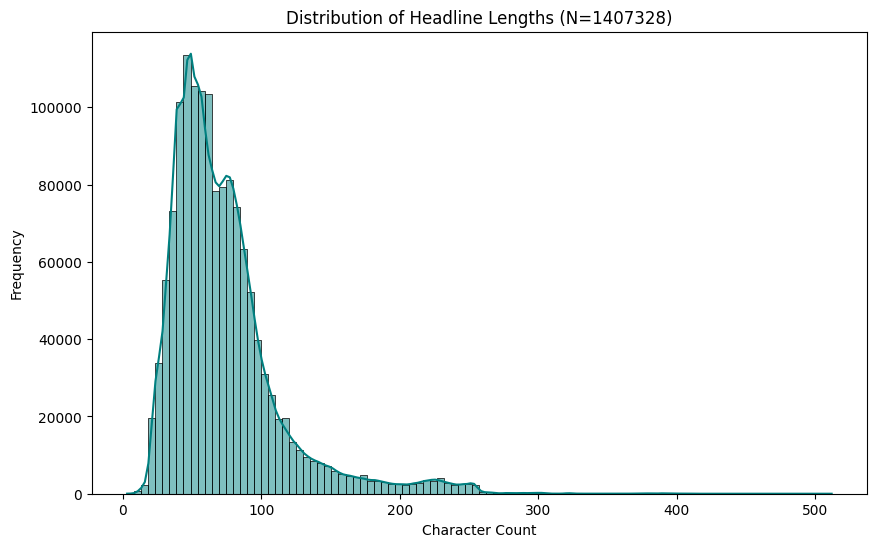

In [3]:
# 1. Calculate character counts
df['headline_len'] = df['headline'].apply(len)

# 2. Output stats
print("--- Headline Statistics ---")
print(df['headline_len'].describe())

# VISUALIZATION 1: Headline Length Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=100, kde=True, color='teal')
plt.title(f'Distribution of Headline Lengths (N={len(df)})')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

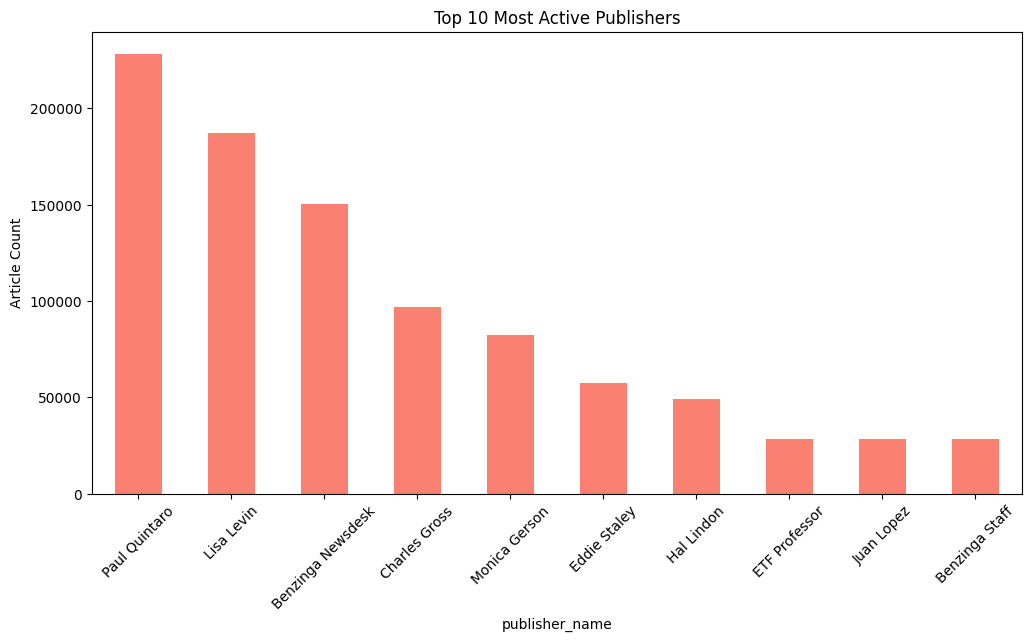


--- Top 5 Publishers ---
publisher_name
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Name: count, dtype: int64


In [4]:
# 1. Extract domain if it looks like an email, else keep name
df['publisher_name'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in str(x) else x)

# 2. Count top 10
top_publishers = df['publisher_name'].value_counts().head(10)

# VISUALIZATION 2: Top Publishers
plt.figure(figsize=(12, 6))
top_publishers.plot(kind='bar', color='salmon')
plt.title('Top 10 Most Active Publishers')
plt.ylabel('Article Count')
plt.xticks(rotation=45)
plt.show()

print("\n--- Top 5 Publishers ---")
print(top_publishers.head(5))

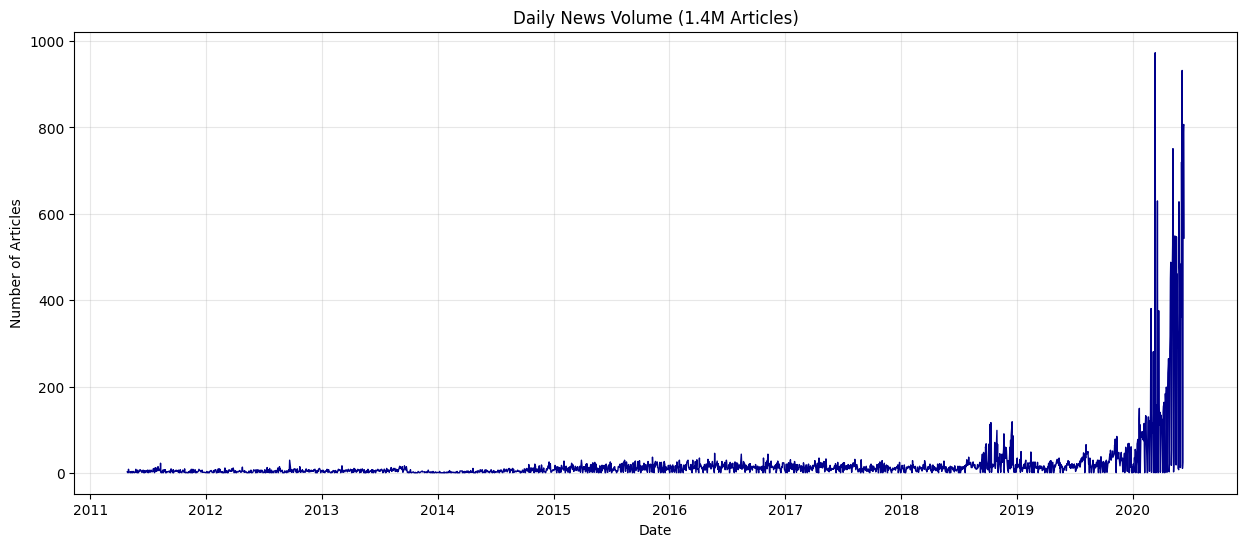


Significant Volume Spike Detected on: 2020-03-12 with 973 articles.


In [5]:
# 1. Aggregate by date
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()

# VISUALIZATION 3: Publication Frequency Over Time
plt.figure(figsize=(15, 6))
daily_counts.plot(color='darkblue', linewidth=1)
plt.title('Daily News Volume (1.4M Articles)')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Detect Spikes (Spikes often correlate with market volatility)
peak_day = daily_counts.idxmax()
print(f"\nSignificant Volume Spike Detected on: {peak_day} with {daily_counts.max()} articles.")

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Get the top recurring phrases (Bigrams)
# This helps identify themes like "price target" or "quarterly earnings"
count_vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bigrams = count_vec.fit_transform(df['headline'].dropna())

# 2. Display the results
features = count_vec.get_feature_names_out()
counts = bigrams.toarray().sum(axis=0)
themes = dict(zip(features, counts))

print("\n--- Top 10 Recurring Themes ---")
for theme, count in sorted(themes.items(), key=lambda x: x[1], reverse=True):
    print(f"{theme.upper()}: {count} mentions")


--- Top 10 Recurring Themes ---
52 WEEK: 51006 mentions
PRICE TARGET: 47274 mentions
STOCKS MOVING: 40044 mentions
MID DAY: 37324 mentions
MARKET UPDATE: 33101 mentions
EARNINGS SCHEDULED: 32055 mentions
INITIATES COVERAGE: 28993 mentions
PRE MARKET: 28393 mentions
RAISES PT: 27213 mentions
COMPANIES TRADING: 23170 mentions
